# Comment Category Prediction

## Submission By:

- **Name:** Varun Agnihotri
- **Roll Number:** `24f2004142`

## Import all the required libraries

In [1]:
import gc
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.sparse import csr_matrix, hstack, issparse
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

## Config

In [2]:
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/input/comment-category-prediction-challenge")
else:
    DATA_DIR = Path("datasets/")

# Ensemble top K models
TOP_K = 3

## Data loading

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(
    DATA_DIR / ("Sample.csv" if IS_KAGGLE else "sample_submission.csv")
)

In [4]:
for _name, _df in [
    ("train", train),
    ("test", test),
    ("sample_sub", sample_sub),
]:
    print(f" {_name} ".center(50, "="))
    print("\nDataset Info:")
    print(_df.info())
    print("\nDataset Description:")
    print(_df.describe(include="all"))
    # print("\nTable Head (10 rows):")
    # print(_df.head(10))
    print("\n\n")

===================== train ======================

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None

Dataset Description:
     

## Helper Functions

In [5]:
def header(msg: str) -> None:
    """
    Print a formatted header message.
    :param msg: Message to be printed as header.
    :return:
    """
    print("\n" + "=" * 50)
    print(msg.center(50))
    print("=" * 50)

In [6]:
def clean_text(text: str) -> str:
    """
    Clean the input text by removing URLs, special characters, and extra spaces.
    :param text: Input text string.
    :return: Cleaned text string.
    """
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

In [7]:
def calc_sparsity(matrix) -> float:
    """
    Calculate the sparsity of a given matrix.
    :param matrix: Input matrix (numpy array or sparse matrix).
    :return: Sparsity in percentage.
    """
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero_elements = matrix.nnz if issparse(matrix) else np.count_nonzero(matrix)
    sparsity = 1.0 - (non_zero_elements / total_elements)
    return sparsity * 100

## Exploratory Data Analysis

In [8]:
train.shape, test.shape, sample_sub.shape

((198000, 15), (102000, 14), (102000, 2))

In [9]:
train.sample(10)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
62714,2023-07-20 23:38:28.512788+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,Koch industries are involved in a lot of consp...,2
97190,2024-04-07 20:18:05.953871+00:00,120,0,0,1,3,0,0,4,NaN,NaN,NaN,False,"Where do you read that? I see them state ""out...",0
16023,2022-11-27 01:31:17.579393+00:00,39,0,0,0,1,0,0,4,NaN,NaN,NaN,False,"""......meeting in secret to try to strike a co...",0
178875,2023-07-04 04:17:14.577589+00:00,111,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Sadly, we don't all share the saem constitutio...",0
114922,2024-02-07 22:56:01.838585+00:00,72,0,0,0,13,0,0,4,NaN,NaN,NaN,False,The Canadian Taxpayers Federation pa has an on...,0
59035,2023-11-08 03:12:06.978423+00:00,72,0,0,0,0,0,4,10,none,none,none,False,I will vote for the NDP if only for their poli...,2
109645,2024-05-26 02:16:49.656044+00:00,72,0,0,1,0,0,0,6,NaN,NaN,NaN,False,Your right - they are ideal Liberals.,0
160223,2024-02-19 00:25:59.391076+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"I wish there was at least a hint of ""cognitive...",2
70620,2024-02-12 22:51:10.656126+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Strada, what would it take for you to reconsid...",2
111165,2023-12-02 14:24:20.596781+00:00,73,0,0,0,10,0,4,4,none,none,none,False,“. . . the measure that the Legislature is con...,0


In [10]:
# Label distribution
print(train["label"].value_counts())
print(f"\nProportions:\n{train['label'].value_counts(normalize=True)}")

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Proportions:
label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


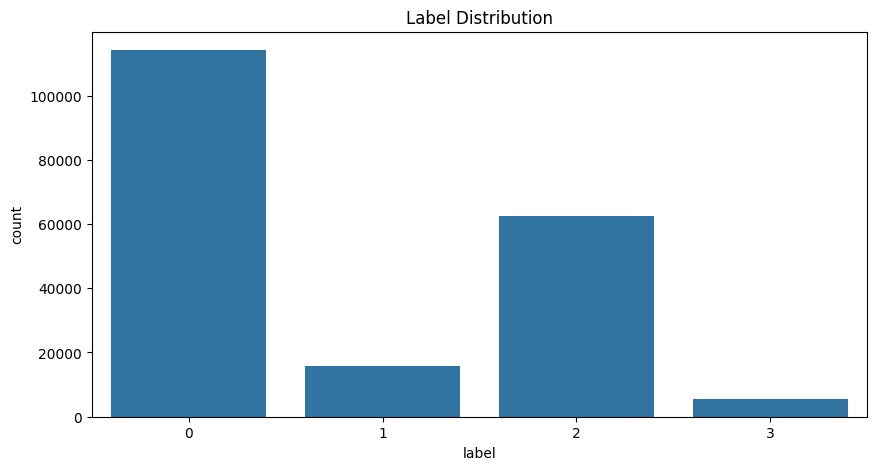

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train, x="label")
plt.title("Label Distribution")
plt.show()

In [12]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


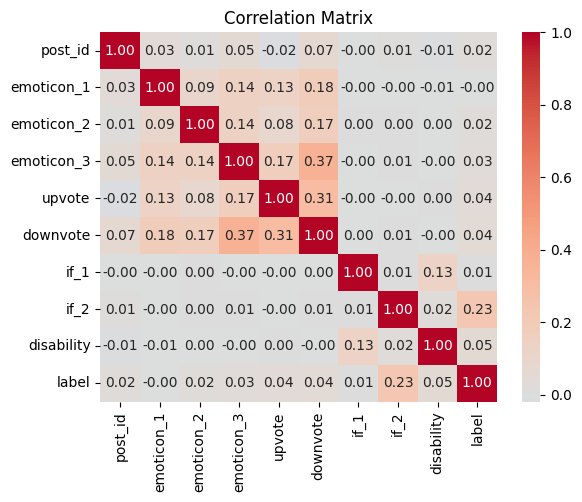

In [13]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [14]:
train["comment_length"] = train["comment"].str.len()
train["word_count"] = train["comment"].str.split().str.len()

header("TEXT STATISTICS BY LABEL")
print(train.groupby("label")[["comment_length", "word_count"]].mean())


             TEXT STATISTICS BY LABEL             
       comment_length  word_count
label                            
0          295.899844   51.187787
1          335.709700   57.233446
2          316.893418   54.901537
3          194.171695   34.978424


## Feature Engineering

In [15]:
def create_features(df):
    df = df.copy()

    # Text features
    df["comment_length"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["avg_word_length"] = df["comment"].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
    )

    # Special characters
    df["exclamation_count"] = df["comment"].str.count("!")
    df["question_count"] = df["comment"].str.count("\\?")
    df["capital_ratio"] = df["comment"].apply(
        lambda x: (
            sum(1 for c in str(x) if c.isupper()) / len(str(x))
            if len(str(x)) > 0
            else 0
        )
    )

    # Engagement features
    df["total_votes"] = df["upvote"] + df["downvote"]
    df["vote_ratio"] = np.where(
        df["total_votes"] > 0, df["upvote"] / df["total_votes"], 0.5
    )
    df["vote_diff"] = df["upvote"] - df["downvote"]
    df["log_upvote"] = np.log1p(df["upvote"])
    df["log_downvote"] = np.log1p(df["downvote"])

    # Temporal features
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["hour"] = df["created_date"].dt.hour
    df["day_of_week"] = df["created_date"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)

    # Emoticon features
    df["total_emoticons"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]

    # Post-level aggregations
    post_stats = (
        df.groupby("post_id")
        .agg({"upvote": ["mean", "count"], "downvote": "mean"})
        .reset_index()
    )

    post_stats.columns = [
        "post_id",
        "post_avg_upvote",
        "post_count",
        "post_avg_downvote",
    ]

    df = df.merge(post_stats, on="post_id", how="left")
    df["upvote_vs_post"] = df["upvote"] - df["post_avg_upvote"]
    df["downvote_vs_post"] = df["downvote"] - df["post_avg_downvote"]

    return df

In [16]:
train = create_features(train)
test = create_features(test)

In [17]:
print(f"Total Features: {len(train.columns)}")

Total Features: 36


## Model Building

In [18]:
train["comment_clean"] = train["comment"].apply(clean_text)
test["comment_clean"] = test["comment"].apply(clean_text)

In [19]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)

In [20]:
tfidf_train = tfidf.fit_transform(train["comment_clean"])
tfidf_test = tfidf.transform(test["comment_clean"])

In [21]:
feature_cols = train.select_dtypes(include="number").columns.tolist()

# remove label and post_id (reduce noise) from features
feature_cols = [c for c in feature_cols if c not in ["label", "post_id"]]

In [22]:
X_tab = train[feature_cols].fillna(0)
X_tab_test = test[feature_cols].fillna(0)

In [23]:
scaler = MaxAbsScaler()
X_tab_scaled = scaler.fit_transform(X_tab)
X_tab_test_scaled = scaler.transform(X_tab_test)

In [24]:
# Combine features
X = hstack([tfidf_train, csr_matrix(X_tab_scaled)]).tocsr()
X_sub = hstack([tfidf_test, csr_matrix(X_tab_test_scaled)]).tocsr()
y = train["label"].values

print(f"Training shape: {X.shape}")

Training shape: (198000, 3028)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
header("Sparse Matrix Stats")

print("Train Matrix:")
print(f"\tSparsity: {calc_sparsity(X):.2f}%")
print(f"\tSparse size: {X.data.nbytes / 1e6:.2f} MB")

print("\nSubmission Matrix:")
print(f"\tSparsity: {calc_sparsity(X_sub):.2f}%")
print(f"\tSparse size: {X_sub.data.nbytes / 1e6:.2f} MB")

# Cleanup
gc.collect()


               Sparse Matrix Stats                
Train Matrix:
	Sparsity: 98.13%
	Sparse size: 89.58 MB

Submission Matrix:
	Sparsity: 98.13%
	Sparse size: 46.17 MB


45

In [27]:
models = {
    # Gradient Boosting Models
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        tree_method="hist",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=-1,
        class_weight="balanced",
    ),
    # Tree-Based Ensemble Models
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    # Linear Models
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
    ),
    # Neural Network
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

In [28]:
scores = {}

for model_name, model in models.items():
    header(f"Training {model_name}")
    if model_name == "XGBoost":
        sample_weights = compute_sample_weight("balanced", y_train)
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    val_preds = model.predict(X_test)

    score = f1_score(y_test, val_preds, average="macro")
    scores[model_name] = {
        "score": score,
        "model": model,
    }
    print(f"\t{model_name} Macro F1 Score: {score:.4f}")


                 Training XGBoost                 
	XGBoost Macro F1 Score: 0.7381

                Training LightGBM                 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


	LightGBM Macro F1 Score: 0.7404

              Training RandomForest               
	RandomForest Macro F1 Score: 0.6400

               Training ExtraTrees                
	ExtraTrees Macro F1 Score: 0.4727

           Training LogisticRegression            


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


	LogisticRegression Macro F1 Score: 0.5982

                   Training MLP                   
	MLP Macro F1 Score: 0.6453


In [29]:
# sort scores
scores = list(sorted(scores.items(), key=lambda x: x[1]["score"], reverse=True))

## Hyperparameter Tuning

In [30]:
params_dict = {
    # Gradient Boosting Models
    "XGBoost": {
        "n_estimators": [200, 300, 500],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_child_weight": [1, 5, 10],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 500],
        "num_leaves": [31, 63, 127],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_child_samples": [10, 20, 50],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "class_weight": ["balanced", None],
    },
    "HistGradientBoosting": {
        "max_iter": [200, 300, 500],
        "max_depth": [5, 7, 10, None],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_samples_leaf": [10, 20, 50],
        "l2_regularization": [0, 0.1, 1],
        "class_weight": ["balanced", None],
    },
    # Tree-Based Ensemble Models
    "RandomForest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [10, 15, 20, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.3],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    "ExtraTrees": {
        "n_estimators": [200, 300, 500],
        "max_depth": [10, 15, 20, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.3],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    # Linear Models
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "class_weight": ["balanced", None],
    },
    # Neural Network
    "MLP": {
        "hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.001, 0.01],
        "batch_size": [64, 128, 256],
    },
}

In [31]:
for model_name, model_data in scores[:3]:
    header(f"Hyperparameter Tuning for {model_name}")

    fit_params = {}
    if model_name == "XGBoost":
        weights = compute_sample_weight("balanced", y_train)
        fit_params["sample_weight"] = weights

    search_cv = RandomizedSearchCV(
        estimator=models[model_name],
        param_distributions=params_dict[model_name],
        n_iter=10,
        scoring="f1_macro",
        cv=3,
        verbose=3,
        random_state=42,
        n_jobs=-1,
    )

    search_cv.fit(X_train, y_train, **fit_params)
    scores.append(
        (
            f"{model_name}_Tuned",
            {
                "score": search_cv.best_score_,
                "model": search_cv.best_estimator_,
            },
        )
    )

    print(f"\t{model_name}_Tuned Best Score: {search_cv.best_score_:.4f}")


        Hyperparameter Tuning for LightGBM        
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CV 2/3] END class_weight=None, colsample_bytree=0.9, learning_rate=0.05, min_child_samples=10, n_estimators=500, num_leaves=127, subsample=0.7;, score=0.774 total time=12.6min
[CV 3/3] END class_weight=None, colsample_bytree=0.7, learning_rate=0.05, min_child_samples=10, n_estimators=500, num_leaves=127, subsample=0.9;, score=0.769 total time=12.4min
[CV 1/3] END class_weight=None, colsample_bytree=0.8, learning_rate=0.01, min_child_samples=50, n_estimators=300, num_leaves=31, subsample=0.7;, score=0.704 total time= 9.6min
[CV 2/3] END class_weight=balanced, colsample_bytree=0.9, learning_rate=0.05, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=0.9;, score=0.757 total time=12.0min
[CV 2/3] END class_weight=balanced, colsample_bytree=0.7, learning_rate=0.1, min_child_samples=50, n_estimators=200, num_leaves=31, subsample=0.9;, score=0.751 total time= 4.7min
[CV 1/3] END class_weight=None, colsample_bytree=0.9, learning_rate=0.01, min_child_samples=50, n_estimators=50

In [32]:
# sort scores
scores = list(sorted(scores, key=lambda x: x[1]["score"], reverse=True))

## Ensemble Models

In [33]:
classes = np.unique(y)
test_probs = np.zeros((X_test.shape[0], len(np.unique(y))))
for model_name, model_data in scores[:TOP_K]:
    header(f"Ensemble Model: {model_name}")
    print(f"Macro F1 Score: {model_data['score']:.4f}")

    model = model_data["model"]
    test_probs += model.predict_proba(X_test) / TOP_K
    classes = model.classes_


          Ensemble Model: XGBoost_Tuned           
Macro F1 Score: 0.7750

          Ensemble Model: LightGBM_Tuned          
Macro F1 Score: 0.7683


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



             Ensemble Model: LightGBM             
Macro F1 Score: 0.7404


In [34]:
header("Ensemble Model Results")
ensemble_pred_indices = np.argmax(test_probs, axis=1)
ensemble_preds = classes[ensemble_pred_indices]

ensemble_model_name = f"Ensemble_Top_{TOP_K}"
ensemble_score = f1_score(y_test, ensemble_preds, average="macro")

scores.append(
    (
        ensemble_model_name,
        {
            "score": ensemble_score,
            "model": None,
        },
    )
)

print(f"Ensemble Macro F1 Score: {ensemble_score:.4f}")

print("\nEnsemble Classification Report:")
print(classification_report(y_test, ensemble_preds))


              Ensemble Model Results              
Ensemble Macro F1 Score: 0.7868

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22534
           1       0.72      0.79      0.75      3219
           2       0.86      0.87      0.86     12738
           3       0.55      0.60      0.57      1109

    accuracy                           0.90     39600
   macro avg       0.77      0.80      0.79     39600
weighted avg       0.90      0.90      0.90     39600



## Model Evaluation

In [35]:
scores = list(sorted(scores, key=lambda x: x[1]["score"], reverse=True))

header("Final Leaderboard")
print(f"{'Rank':<5} {'Model Name':<25} {'Score':<10}")
print("-" * 40)

for rank, (name, data) in enumerate(scores, 1):
    print(f"{rank:<5} {name:<25} {data['score']:.4f}")

# Update best_model_data to the new #1
best_model_name, best_model_data = scores[0]
print(
    f"\n>> New Best Model: {best_model_name} with Score: {best_model_data['score']:.4f}"
)


                Final Leaderboard                 
Rank  Model Name                Score     
----------------------------------------
1     Ensemble_Top_3            0.7868
2     XGBoost_Tuned             0.7750
3     LightGBM_Tuned            0.7683
4     LightGBM                  0.7404
5     XGBoost                   0.7381
6     MLP_Tuned                 0.7264
7     MLP                       0.6453
8     RandomForest              0.6400
9     LogisticRegression        0.5982
10    ExtraTrees                0.4727

>> New Best Model: Ensemble_Top_3 with Score: 0.7868


## Predicting Test Data

In [36]:
if best_model_name == ensemble_model_name:
    # Use ensemble model
    final_probs = np.zeros((X_sub.shape[0], len(np.unique(y))))
    print("Generating Ensemble submission...")
    header("Retraining Top Models on Full Data")
    for model_name, model_data in scores[1 : TOP_K + 1]:
        print(f"Retraining {model_name}...")
        print(f"Macro F1 Score: {model_data['score']:.4f}")

        print("\nRetraining on full training data...")
        model = model_data["model"]

        if "XGBoost" in model_name:
            sample_weights = compute_sample_weight("balanced", y)
            model.fit(X, y, sample_weight=sample_weights)
        else:
            model.fit(X, y)

        # Final predictions
        model_preds = model.predict_proba(X_sub)
        final_probs += model_preds * (1 / TOP_K)
else:
    # Use single best model
    print(
        f"Ensemble score ({ensemble_score:.4f}) did not beat single best model ({best_model_data['score']:.4f})."
    )

    header(f"Best Model: {best_model_name}")
    print(f"Macro F1 Score: {best_model_data['score']:.4f}")

    print("\nClassification Report:")
    best_val_preds = best_model_data["model"].predict(X_test)
    print(classification_report(y_test, best_val_preds))

    print("\nRetraining on full training data...")
    model = best_model_data["model"]

    if "XGBoost" in best_model_name:
        sample_weights = compute_sample_weight("balanced", y)
        model.fit(X, y, sample_weight=sample_weights)
    else:
        model.fit(X, y)

    final_probs = model.predict_proba(X_sub)

# Final predictions
final_pred_indices = np.argmax(final_probs, axis=1)
final_preds = classes[final_pred_indices]
print("Final submission generated.")

Generating Ensemble submission...

        Retraining Top Models on Full Data        
Retraining XGBoost_Tuned...
Macro F1 Score: 0.7750

Retraining on full training data...
Retraining LightGBM_Tuned...
Macro F1 Score: 0.7683

Retraining on full training data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Retraining LightGBM...
Macro F1 Score: 0.7404

Retraining on full training data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final submission generated.


## Final Submission

In [37]:
submission = pd.DataFrame({"ID": test.index + 1, "label": final_preds})
submission.to_csv("submission.csv", index=False)

header("Submission created!")
print(submission["label"].value_counts())


               Submission created!                
label
0    57055
2    32787
1     8952
3     3206
Name: count, dtype: int64
